# NVIDIA Stock Historical Price
dataset: https://www.kaggle.com/datasets/caesarmario/nvidia-stock-historical-price

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# Cargar dataset
df = pd.read_csv("C:/Users/aaran/Downloads/NVIDIA Stock Historical Price/NVDA.csv")

# Mostrar primeras filas
print(df.head())

         Date     open     high      low    close  adjclose     volume  \
0  2016-01-04  0.80725  0.81450  0.80100  0.80925  0.788626  358076000   
1  2016-01-05  0.82450  0.83600  0.81250  0.82225  0.801295  490272000   
2  2016-01-06  0.80875  0.81250  0.77900  0.78825  0.768161  449344000   
3  2016-01-07  0.76850  0.77375  0.74700  0.75700  0.737708  645304000   
4  2016-01-08  0.76675  0.76750  0.73925  0.74075  0.721872  398472000   

                    ingested_at_utc  
0  2026-08-17 06:00:39.327695+00:00  
1  2026-08-17 06:00:39.327695+00:00  
2  2026-08-17 06:00:39.327695+00:00  
3  2026-08-17 06:00:39.327695+00:00  
4  2026-08-17 06:00:39.327695+00:00  


In [4]:
print("DIMENSIONES DEL DATASET")
print(df.shape)

print("\nCOLUMNAS")
print(df.columns)

print("\nINFORMACIÓN GENERAL")
df.info()

print("\nPRIMERAS FILAS")
print(df.head())

print("\nÚLTIMAS FILAS")
print(df.tail())

print("\nESTADÍSTICAS")
print(df.describe())

DIMENSIONES DEL DATASET
(2669, 8)

COLUMNAS
Index(['Date', 'open', 'high', 'low', 'close', 'adjclose', 'volume',
       'ingested_at_utc'],
      dtype='str')

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 2669 entries, 0 to 2668
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2669 non-null   str    
 1   open             2669 non-null   float64
 2   high             2669 non-null   float64
 3   low              2669 non-null   float64
 4   close            2669 non-null   float64
 5   adjclose         2669 non-null   float64
 6   volume           2669 non-null   int64  
 7   ingested_at_utc  2669 non-null   str    
dtypes: float64(5), int64(1), str(2)
memory usage: 276.4 KB

PRIMERAS FILAS
         Date     open     high      low    close  adjclose     volume  \
0  2016-01-04  0.80725  0.81450  0.80100  0.80925  0.788626  358076000   
1  2016-01-05  0.82450  0.83600  0.81250 

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["ingested_at_utc"] = pd.to_datetime(
    df["ingested_at_utc"],
    utc=True
)

print(df.dtypes)

Date                    datetime64[us]
open                           float64
high                           float64
low                            float64
close                          float64
adjclose                       float64
volume                           int64
ingested_at_utc    datetime64[us, UTC]
dtype: object


In [6]:
df = df.sort_values("Date").reset_index(drop=True)

In [7]:
nulos = df.isnull().sum()

porcentaje_nulos = df.isnull().mean() * 100

tabla_nulos = pd.DataFrame({
    "Cantidad_nulos": nulos,
    "Porcentaje": porcentaje_nulos
})

print(tabla_nulos)

                 Cantidad_nulos  Porcentaje
Date                          0         0.0
open                          0         0.0
high                          0         0.0
low                           0         0.0
close                         0         0.0
adjclose                      0         0.0
volume                        0         0.0
ingested_at_utc               0         0.0


In [8]:
print("Filas duplicadas:")
print(df.duplicated().sum())

Filas duplicadas:
0


In [9]:
print("Fechas duplicadas:")
print(df["Date"].duplicated().sum())

Fechas duplicadas:
0


In [10]:
for columna in df.columns:
    print(
        columna,
        "->",
        df[columna].nunique(),
        "valores únicos"
    )

Date -> 2669 valores únicos
open -> 2592 valores únicos
high -> 2600 valores únicos
low -> 2607 valores únicos
close -> 2611 valores únicos
adjclose -> 2642 valores únicos
volume -> 2661 valores únicos
ingested_at_utc -> 1 valores únicos


In [11]:
print(df["ingested_at_utc"].nunique())

1


In [12]:
df = df.drop(columns=["ingested_at_utc"])

In [13]:
errores_high = df[
    (df["high"] < df["open"]) |
    (df["high"] < df["close"]) |
    (df["high"] < df["low"])
]

errores_low = df[
    (df["low"] > df["open"]) |
    (df["low"] > df["close"]) |
    (df["low"] > df["high"])
]

print("Errores en High:", len(errores_high))
print("Errores en Low:", len(errores_low))

Errores en High: 0
Errores en Low: 0


In [14]:
features = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume"
]

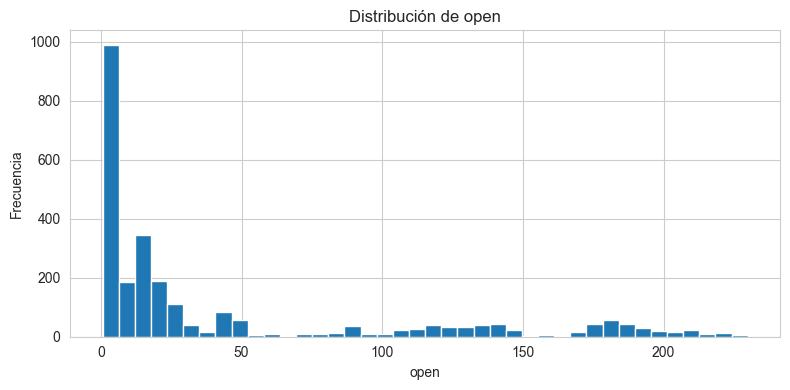

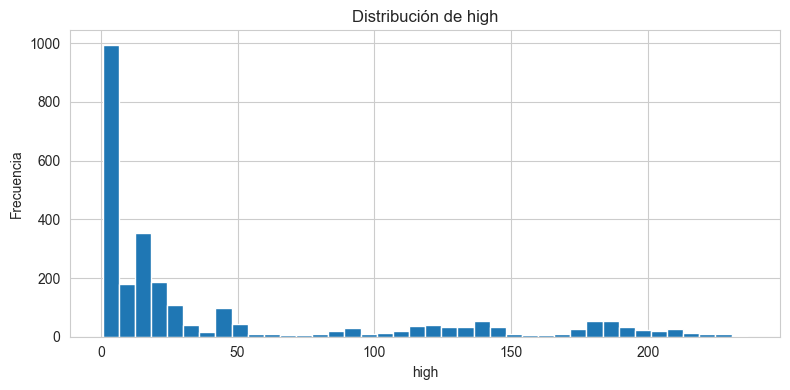

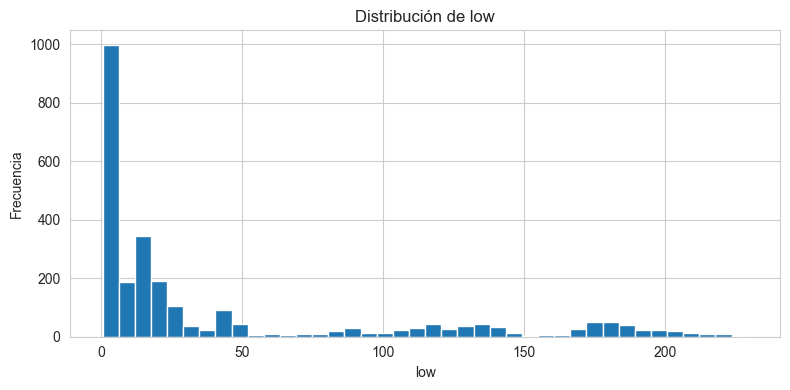

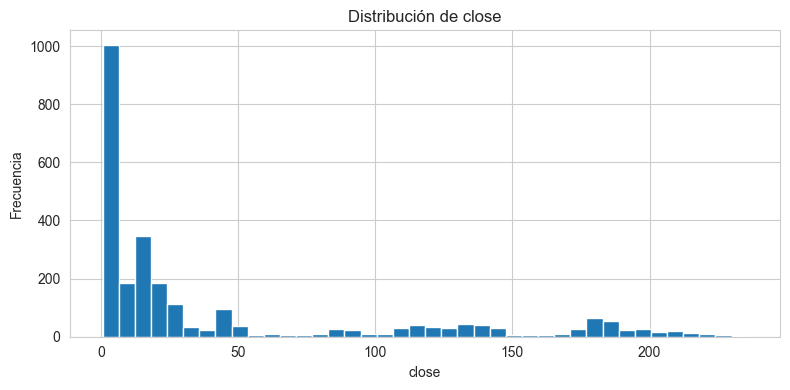

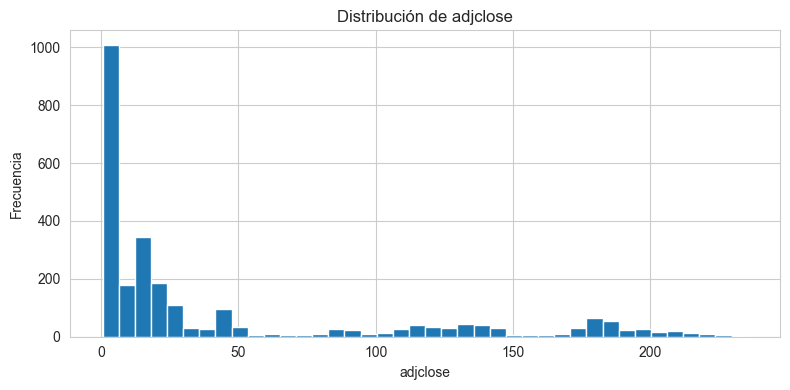

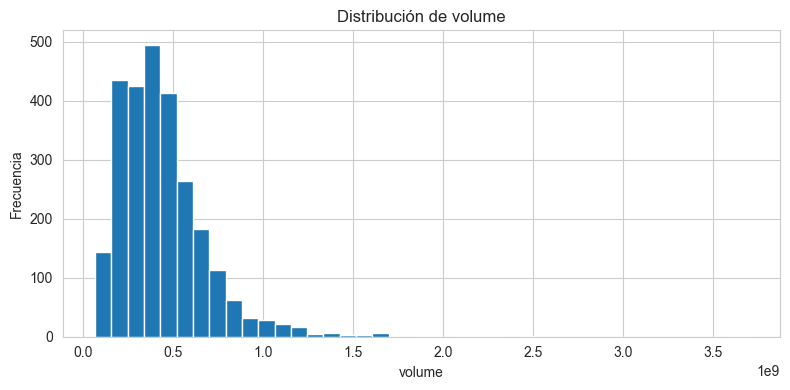

In [15]:
for feature in features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[feature].dropna(),
        bins=40
    )

    plt.title(f"Distribución de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

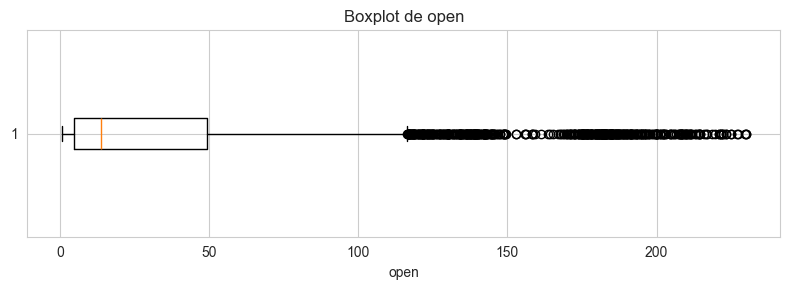

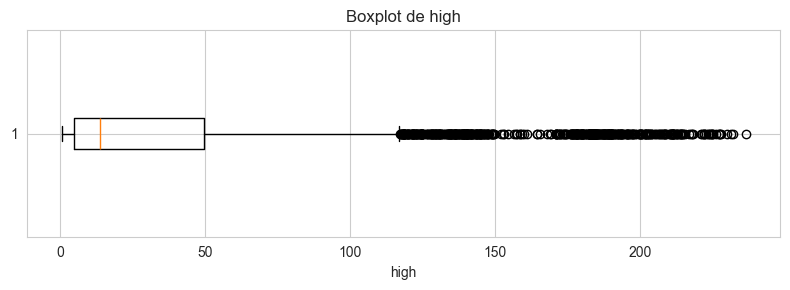

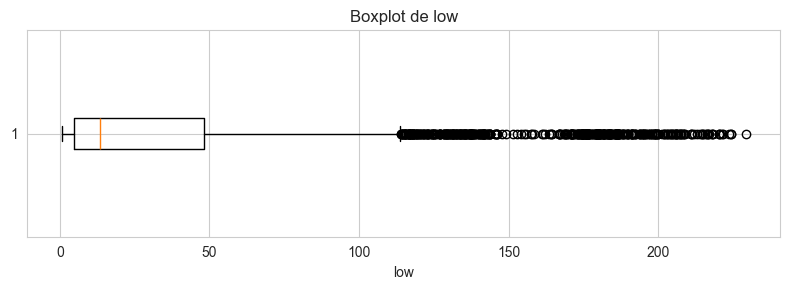

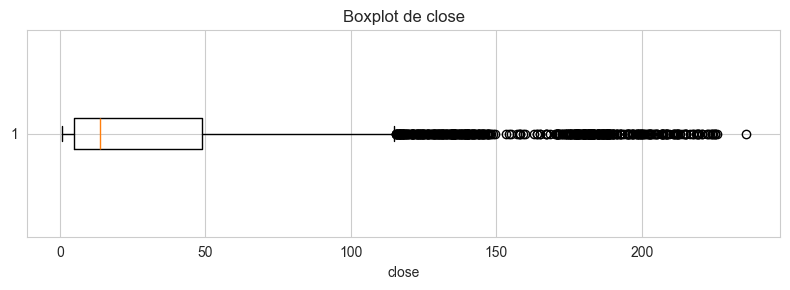

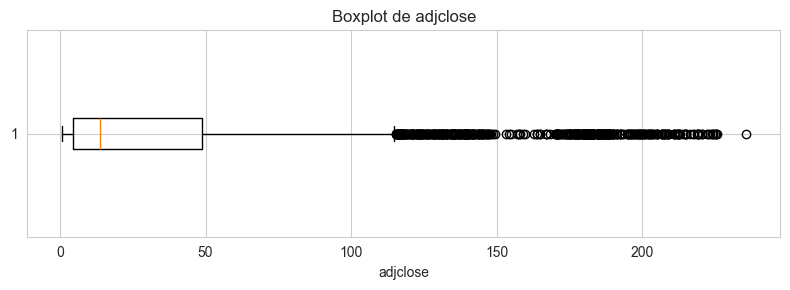

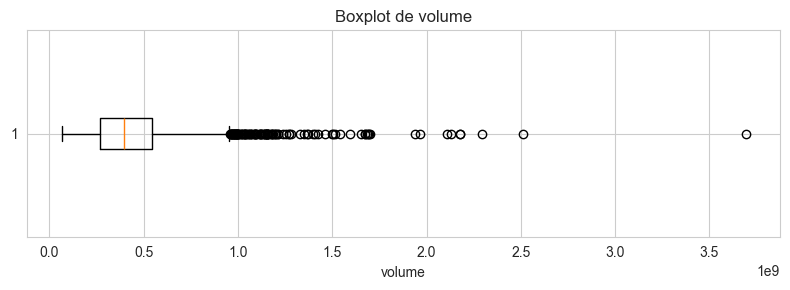

In [16]:
for feature in features:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[feature].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

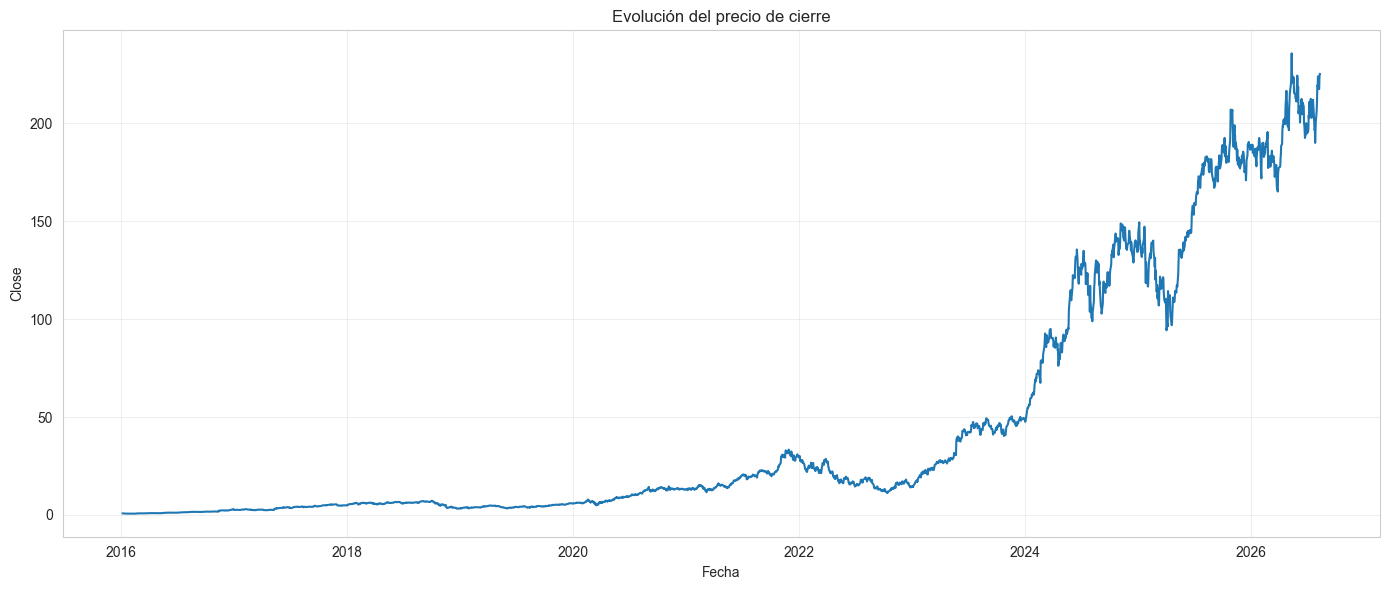

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["close"]
)

plt.title("Evolución del precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Close")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

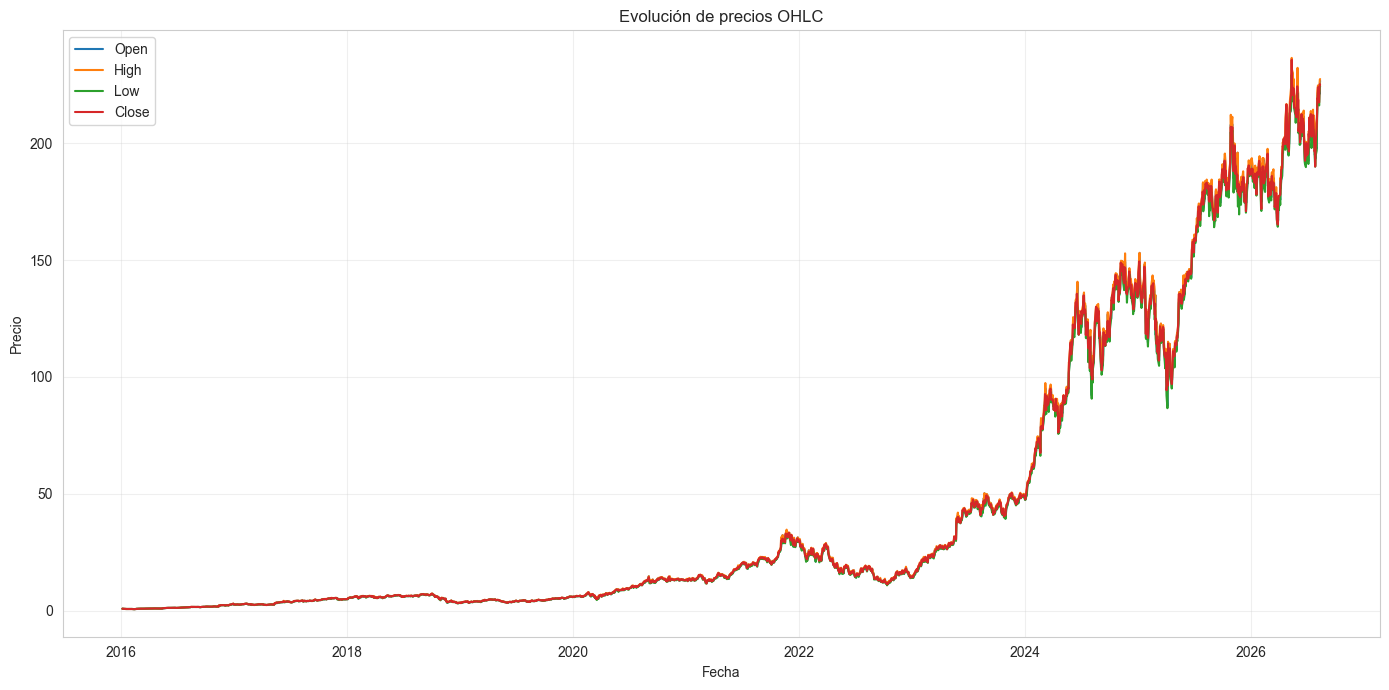

In [18]:
plt.figure(figsize=(14, 7))

plt.plot(df["Date"], df["open"], label="Open")
plt.plot(df["Date"], df["high"], label="High")
plt.plot(df["Date"], df["low"], label="Low")
plt.plot(df["Date"], df["close"], label="Close")

plt.title("Evolución de precios OHLC")
plt.xlabel("Fecha")
plt.ylabel("Precio")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

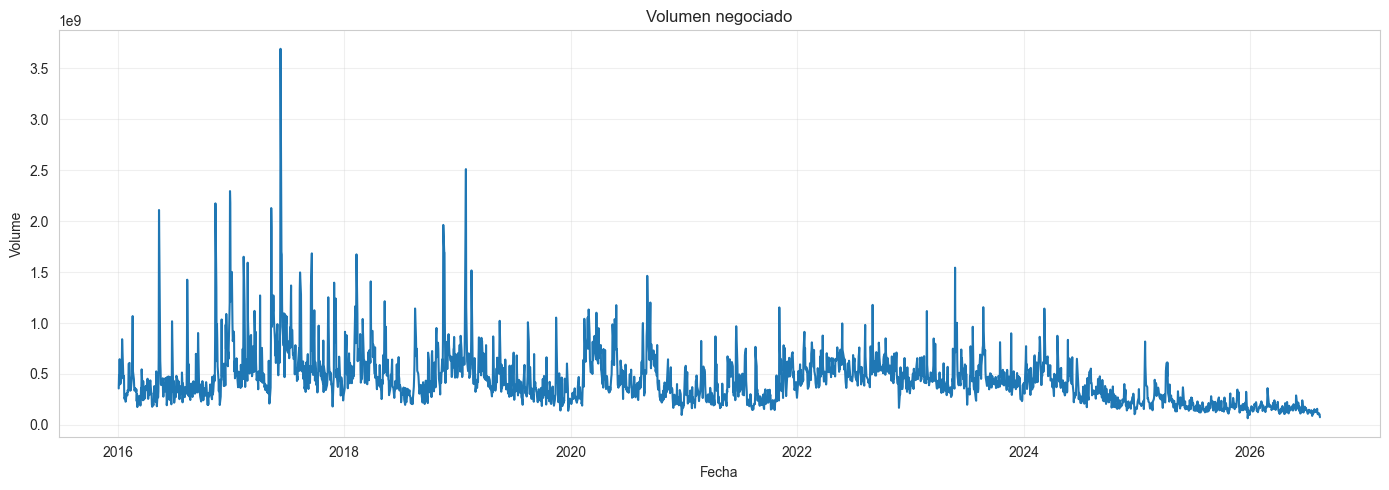

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["volume"]
)

plt.title("Volumen negociado")
plt.xlabel("Fecha")
plt.ylabel("Volume")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
features = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume"
]

corr = df[features].corr()

print(corr)

              open      high       low     close  adjclose    volume
open      1.000000  0.999856  0.999808  0.999618  0.999617 -0.440652
high      0.999856  1.000000  0.999797  0.999827  0.999827 -0.439267
low       0.999808  0.999797  1.000000  0.999850  0.999850 -0.442730
close     0.999618  0.999827  0.999850  1.000000  1.000000 -0.441221
adjclose  0.999617  0.999827  0.999850  1.000000  1.000000 -0.441249
volume   -0.440652 -0.439267 -0.442730 -0.441221 -0.441249  1.000000


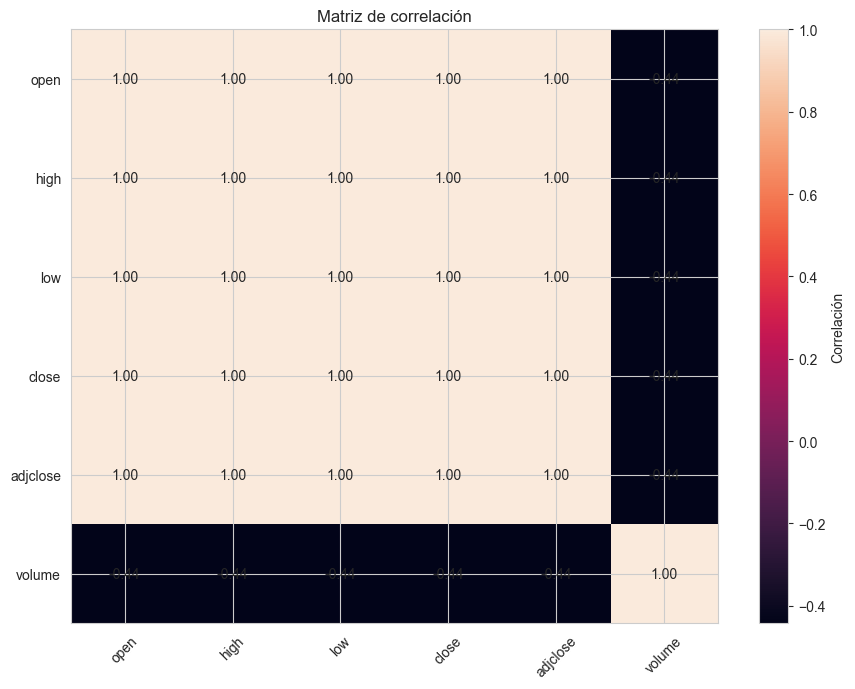

In [21]:
plt.figure(figsize=(9, 7))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Matriz de correlación")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):

        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [23]:
corr = df.corr()

15. Crear la variable objetivo correctamente

In [24]:
df["target_close_next_day"] = df["close"].shift(-1)

In [25]:
print(
    df[
        ["Date", "close", "target_close_next_day"]
    ].head(10)
)

        Date    close  target_close_next_day
0 2016-01-04  0.80925                0.82225
1 2016-01-05  0.82225                0.78825
2 2016-01-06  0.78825                0.75700
3 2016-01-07  0.75700                0.74075
4 2016-01-08  0.74075                0.74200
5 2016-01-11  0.74200                0.75450
6 2016-01-12  0.75450                0.73150
7 2016-01-13  0.73150                0.71675
8 2016-01-14  0.71675                0.67775
9 2016-01-15  0.67775                0.68325


In [26]:
features = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume"
]

correlacion_target = (
    df[features + ["target_close_next_day"]]
    .corr()["target_close_next_day"]
    .drop("target_close_next_day")
    .sort_values(ascending=False)
)

print(correlacion_target)

close       0.999435
adjclose    0.999435
low         0.999315
high        0.999297
open        0.999117
volume     -0.440244
Name: target_close_next_day, dtype: float64


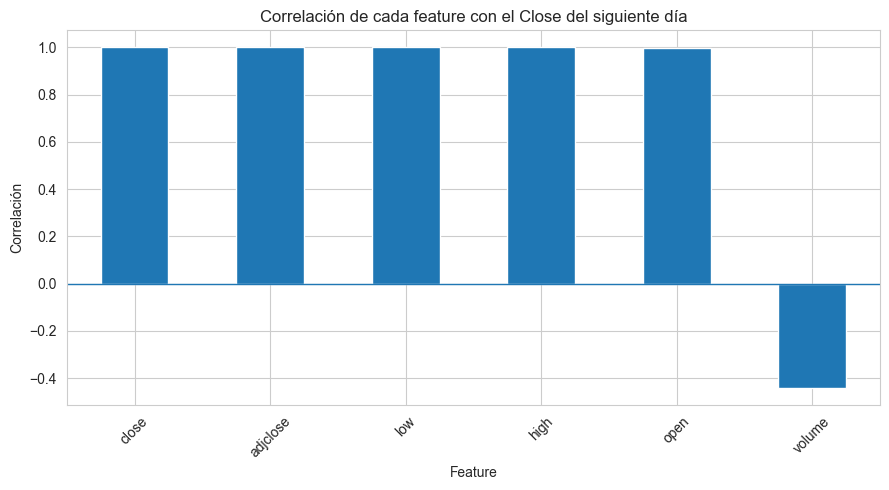

In [27]:
plt.figure(figsize=(9, 5))

correlacion_target.plot(kind="bar")

plt.title(
    "Correlación de cada feature con el Close del siguiente día"
)

plt.ylabel("Correlación")
plt.xlabel("Feature")

plt.axhline(
    y=0,
    linewidth=1
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 2669 entries, 0 to 2668
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Date             2669 non-null   datetime64[us]     
 1   open             2669 non-null   float64            
 2   high             2669 non-null   float64            
 3   low              2669 non-null   float64            
 4   close            2669 non-null   float64            
 5   adjclose         2669 non-null   float64            
 6   volume           2669 non-null   int64              
 7   ingested_at_utc  2669 non-null   datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(1)
memory usage: 166.9 KB
None

Dimensiones:
(2669, 8)

Estadísticas:
                             Date         open         high          low  \
count                        2669  2669.000000  2669.000000  2669.000000   
mean   2021-04-22 03:38:30.528287 

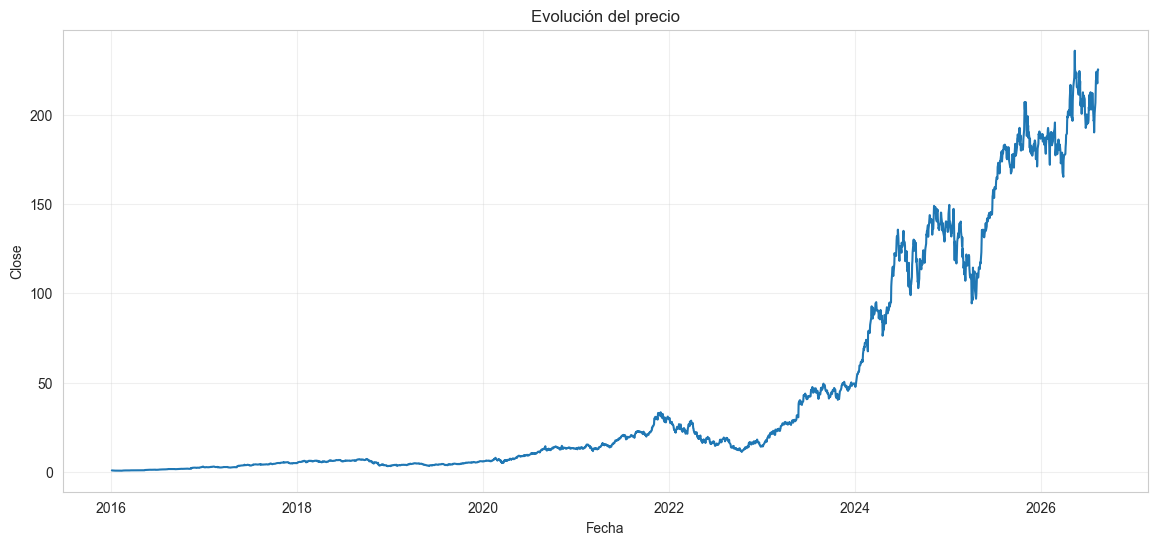

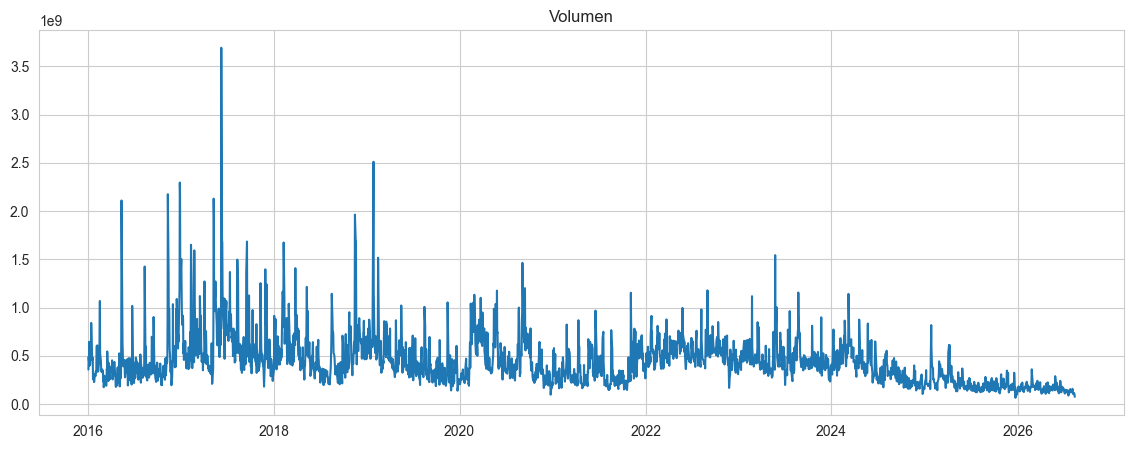

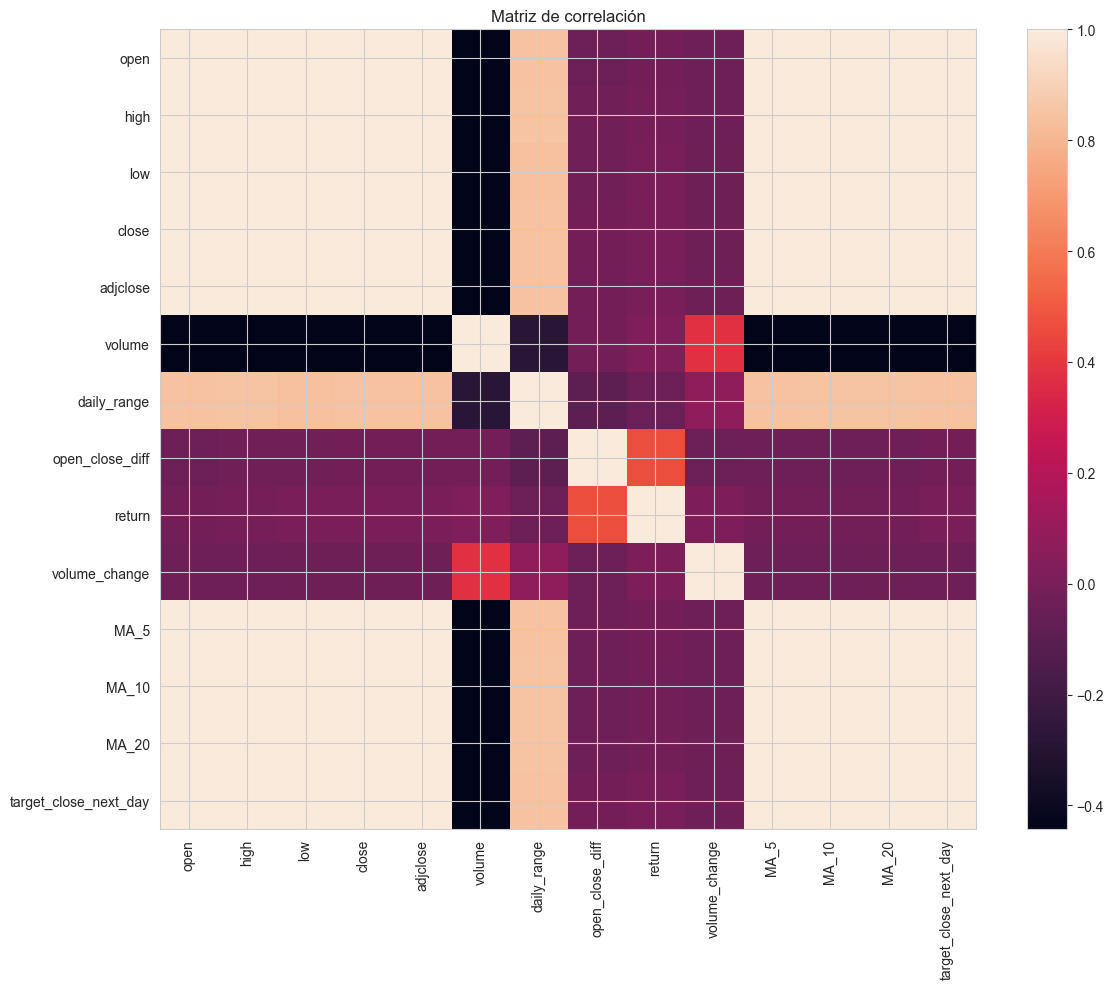


CORRELACIÓN CON EL TARGET
close              0.999435
adjclose           0.999435
low                0.999315
high               0.999297
open               0.999117
MA_5               0.998870
MA_10              0.998271
MA_20              0.997207
daily_range        0.843360
return             0.001410
open_close_diff   -0.011947
volume_change     -0.029990
volume            -0.440244
Name: target_close_next_day, dtype: float64


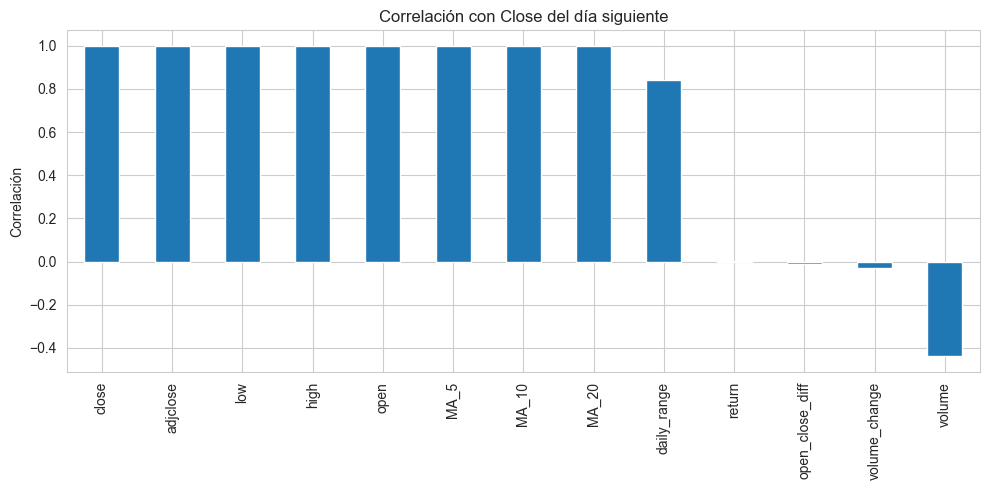

direction
Sube    54.552267
Baja    45.447733
Name: proportion, dtype: float64


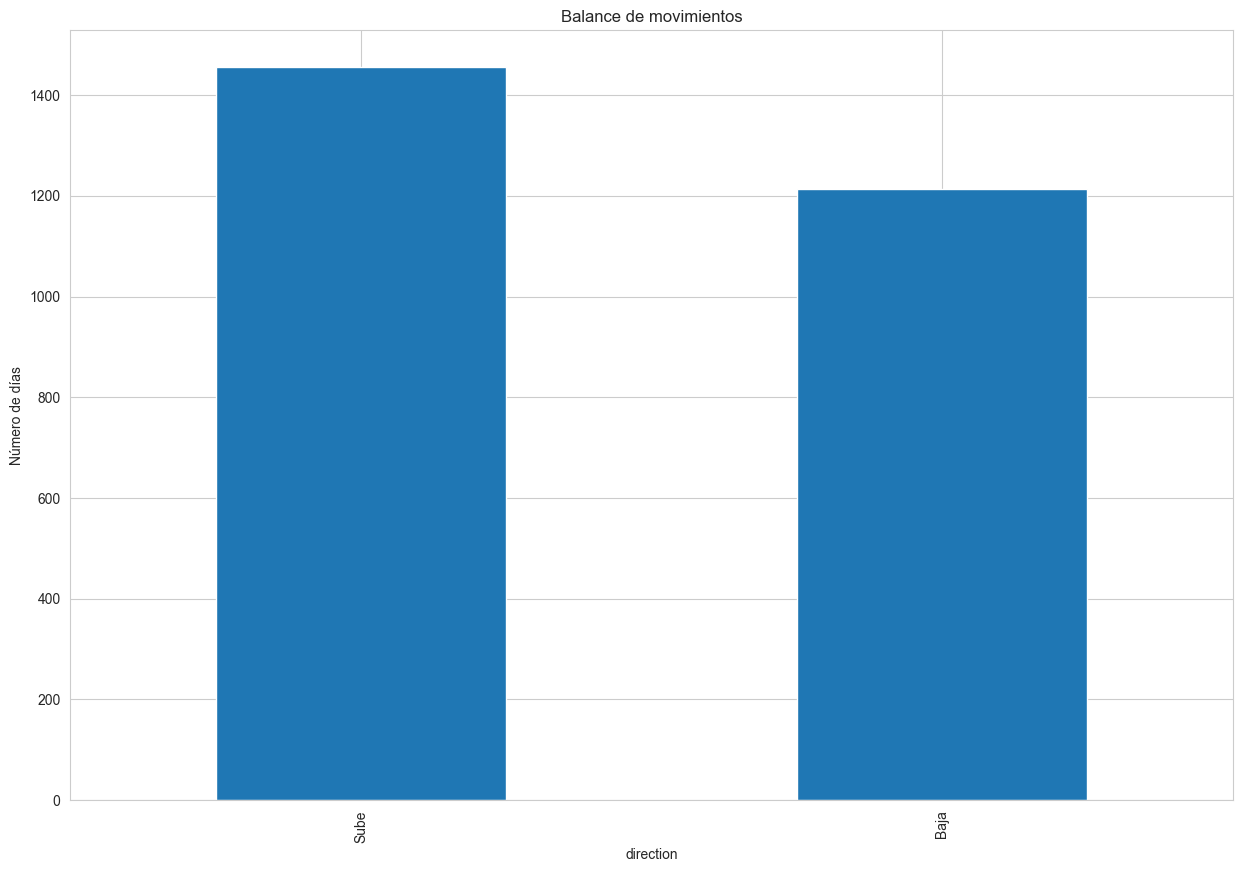

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression


# =========================================================
# 2. FECHAS
# =========================================================

df["Date"] = pd.to_datetime(df["Date"])

df["ingested_at_utc"] = pd.to_datetime(
    df["ingested_at_utc"],
    utc=True
)

df = df.sort_values("Date").reset_index(drop=True)

# =========================================================
# 3. INFORMACIÓN GENERAL
# =========================================================

print(df.info())

print("\nDimensiones:")
print(df.shape)

print("\nEstadísticas:")
print(df.describe())

# =========================================================
# 4. NULOS
# =========================================================

tabla_nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

print("\nNulos:")
print(tabla_nulos)

# =========================================================
# 5. DUPLICADOS
# =========================================================

print("\nFilas duplicadas:")
print(df.duplicated().sum())

print("\nFechas duplicadas:")
print(df["Date"].duplicated().sum())

# =========================================================
# 6. COLUMNAS CONSTANTES
# =========================================================

print("\nValores únicos:")

print(
    df.nunique().sort_values()
)

# Eliminar metadata si es constante

if df["ingested_at_utc"].nunique() <= 1:

    df = df.drop(
        columns=["ingested_at_utc"]
    )

# =========================================================
# 7. FEATURES BÁSICAS
# =========================================================

features = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume"
]

# =========================================================
# 8. TARGET = CLOSE DEL DÍA SIGUIENTE
# =========================================================

df["target_close_next_day"] = (
    df["close"].shift(-1)
)

# =========================================================
# 9. FEATURES DERIVADAS
# =========================================================

df["daily_range"] = (
    df["high"] - df["low"]
)

df["open_close_diff"] = (
    df["close"] - df["open"]
)

df["return"] = (
    df["close"].pct_change()
)

df["volume_change"] = (
    df["volume"].pct_change()
)

df["MA_5"] = (
    df["close"].rolling(5).mean()
)

df["MA_10"] = (
    df["close"].rolling(10).mean()
)

df["MA_20"] = (
    df["close"].rolling(20).mean()
)

# =========================================================
# 10. GRÁFICA DEL PRECIO
# =========================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["close"]
)

plt.title("Evolución del precio")
plt.xlabel("Fecha")
plt.ylabel("Close")

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# 11. VOLUMEN
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["volume"]
)

plt.title("Volumen")

plt.show()

# =========================================================
# 12. CORRELACIONES
# =========================================================

variables_corr = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume",
    "daily_range",
    "open_close_diff",
    "return",
    "volume_change",
    "MA_5",
    "MA_10",
    "MA_20",
    "target_close_next_day"
]

corr = df[variables_corr].corr()

plt.figure(figsize=(12, 10))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Matriz de correlación")

plt.tight_layout()

plt.show()

# =========================================================
# 13. CORRELACIÓN CONTRA TARGET
# =========================================================

corr_target = (
    corr["target_close_next_day"]
    .drop("target_close_next_day")
    .sort_values(ascending=False)
)

print("\nCORRELACIÓN CON EL TARGET")

print(corr_target)

plt.figure(figsize=(10, 5))

corr_target.plot(
    kind="bar"
)

plt.title(
    "Correlación con Close del día siguiente"
)

plt.ylabel("Correlación")

plt.tight_layout()

plt.show()

# =========================================================
# 14. BALANCE SUBIDAS / BAJADAS
# =========================================================

df["direction"] = np.where(
    df["return"] >= 0,
    "Sube",
    "Baja"
)

print(
    df["direction"]
    .value_counts(normalize=True)
    * 100
)

df["direction"].value_counts().plot(
    kind="bar"
)

plt.title("Balance de movimientos")
plt.ylabel("Número de días")

plt.show()

In [32]:
import pandas as pd
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# CONFIGURACIÓN
# ============================================================

features = [
    "open",
    "high",
    "low",
    "close",
    "adjclose",
    "volume"
]

target = "close"

SEQ_LENGTH = 30
BATCH_SIZE = 64


# ============================================================
# ORDENAR DATOS
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    "Date"
).reset_index(drop=True)


# ============================================================
# SPLIT TEMPORAL
# ============================================================

train_size = int(
    len(df) * 0.70
)

valid_size = int(
    len(df) * 0.15
)


train_df = df.iloc[
    :train_size
].copy()


valid_df = df.iloc[
    train_size:
    train_size + valid_size
].copy()


test_df = df.iloc[
    train_size + valid_size:
].copy()


# ============================================================
# SCALERS
# ============================================================

scaler_X = MinMaxScaler()

scaler_y = MinMaxScaler()


scaler_X.fit(
    train_df[features]
)

scaler_y.fit(
    train_df[[target]]
)


# ============================================================
# TRANSFORMAR DATOS
# ============================================================

train_X_scaled = scaler_X.transform(
    train_df[features]
)

valid_X_scaled = scaler_X.transform(
    valid_df[features]
)

test_X_scaled = scaler_X.transform(
    test_df[features]
)


train_y_scaled = scaler_y.transform(
    train_df[[target]]
)

valid_y_scaled = scaler_y.transform(
    valid_df[[target]]
)

test_y_scaled = scaler_y.transform(
    test_df[[target]]
)


# ============================================================
# CREAR SECUENCIAS
# ============================================================

def create_sequences(
    X,
    y,
    seq_length
):

    sequences = []
    targets = []

    for i in range(
        len(X) - seq_length
    ):

        sequences.append(
            X[i:i + seq_length]
        )

        targets.append(
            y[i + seq_length]
        )

    return (
        np.array(
            sequences,
            dtype=np.float32
        ),

        np.array(
            targets,
            dtype=np.float32
        )
    )


X_train, Y_train = create_sequences(
    train_X_scaled,
    train_y_scaled,
    SEQ_LENGTH
)


X_valid, Y_valid = create_sequences(
    valid_X_scaled,
    valid_y_scaled,
    SEQ_LENGTH
)


X_test, Y_test = create_sequences(
    test_X_scaled,
    test_y_scaled,
    SEQ_LENGTH
)


# ============================================================
# DATASET PYTORCH
# ============================================================

class TimeSeriesDataset(Dataset):

    def __init__(
        self,
        X,
        y=None
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = None

        if y is not None:

            self.y = torch.tensor(
                y,
                dtype=torch.float32
            )


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        if self.y is not None:

            return (
                self.X[ix],
                self.y[ix]
            )

        return self.X[ix]


# ============================================================
# DATASETS
# ============================================================

dataset = {

    "train": TimeSeriesDataset(
        X_train,
        Y_train
    ),

    "eval": TimeSeriesDataset(
        X_valid,
        Y_valid
    ),

    "test": TimeSeriesDataset(
        X_test
    )

}


# ============================================================
# DATALOADERS
# ============================================================

dataloader = {

    "train": DataLoader(
        dataset["train"],
        shuffle=True,
        batch_size=BATCH_SIZE
    ),

    "eval": DataLoader(
        dataset["eval"],
        shuffle=False,
        batch_size=BATCH_SIZE
    ),

    "test": DataLoader(
        dataset["test"],
        shuffle=False,
        batch_size=BATCH_SIZE
    )
}


# ============================================================
# COMPROBAR
# ============================================================

X_batch, y_batch = next(
    iter(dataloader["train"])
)

print(
    "X batch:",
    X_batch.shape
)

print(
    "Y batch:",
    y_batch.shape
)

X batch: torch.Size([64, 30, 6])
Y batch: torch.Size([64, 1])


In [40]:
from tqdm import tqdm

def fit(model, dataloader, epochs=50):

    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    criterion = torch.nn.MSELoss()

    history = {
        "train_loss": [],
        "val_loss": []
    }

    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:

        # ==========================================
        # ENTRENAMIENTO
        # ==========================================

        model.train()

        train_losses = []

        for X, y in dataloader["train"]:

            X = X.to(device)
            y = y.to(device)

            # Limpiar gradientes anteriores
            optimizer.zero_grad()

            # Predicción
            y_hat = model(X)

            # Error
            loss = criterion(
                y_hat,
                y
            )

            # Backpropagation
            loss.backward()

            # Actualizar pesos
            optimizer.step()

            train_losses.append(
                loss.item()
            )

        # ==========================================
        # VALIDACIÓN
        # ==========================================

        model.eval()

        val_losses = []

        with torch.no_grad():

            for X, y in dataloader["eval"]:

                X = X.to(device)
                y = y.to(device)

                y_hat = model(X)

                loss = criterion(
                    y_hat,
                    y
                )

                val_losses.append(
                    loss.item()
                )

        # ==========================================
        # PROMEDIOS
        # ==========================================

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        bar.set_description(
            f"Epoch {epoch} | "
            f"Train: {train_loss:.6f} | "
            f"Val: {val_loss:.6f}"
        )

    return history

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [66]:
class DeepRNN(torch.nn.Module):

    def __init__(
        self,
        input_size=6,
        hidden_size=20,
        num_layers=2
    ):

        super().__init__()

        self.rnn = torch.nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        # output:
        # [batch, time_steps, hidden_size]

        output, _ = self.rnn(x)

        # Último instante temporal
        last_output = output[:, -1, :]

        # [batch, hidden_size] -> [batch, 1]
        y = self.fc(last_output)

        return y

In [46]:
model = DeepRNN()

history = fit(
    model,
    dataloader,
    epochs=500
)

Epoch 500 | Train: 0.000132 | Val: 1.313125: 100%|██████████| 500/500 [00:43<00:00, 11.39it/s]


In [52]:
def predict(model, dataloader):

    model.eval()

    predictions = []

    with torch.no_grad():

        for X in dataloader:

            X = X.to(device)

            y_hat = model(X)

            predictions.append(
                y_hat.cpu()
            )

    predictions = torch.cat(
        predictions,
        dim=0
    )

    return predictions.numpy()

In [53]:
predicciones = predict(
    model,
    dataloader["test"]
)

In [54]:
print(predicciones.shape)
print(Y_test.shape)

(371, 1)
(371, 1)


In [55]:
predicciones_reales = scaler_y.inverse_transform(
    predicciones
)

valores_reales = scaler_y.inverse_transform(
    Y_test
)

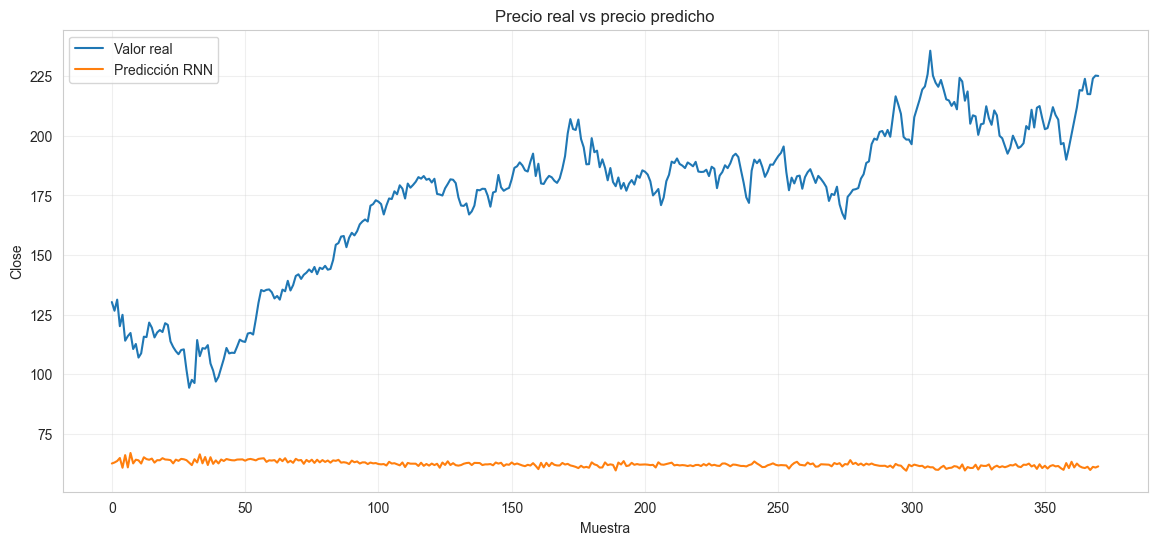

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    valores_reales.flatten(),
    label="Valor real"
)

plt.plot(
    predicciones_reales.flatten(),
    label="Predicción RNN"
)

plt.title("Precio real vs precio predicho")
plt.xlabel("Muestra")
plt.ylabel("Close")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [67]:
class LSTM(DeepRNN):

    def __init__(
        self,
        input_size=6,
        hidden_size=20,
        num_layers=2,
        dropout=0
    ):

        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers
        )

        self.rnn = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

lstm = LSTM()   

In [68]:
lstm

LSTM(
  (rnn): LSTM(6, 20, num_layers=2, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)

In [80]:
history_lstm = fit(
    lstm,
    dataloader,
    epochs=500
)

Epoch 500 | Train: 0.000112 | Val: 1.214523: 100%|██████████| 500/500 [01:05<00:00,  7.64it/s]


In [70]:
class GRU(DeepRNN):

    def __init__(
        self,
        input_size=6,
        hidden_size=20,
        num_layers=2,
        dropout=0
    ):

        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers
        )

        self.rnn = torch.nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

In [71]:
gru = GRU()
gru

GRU(
  (rnn): GRU(6, 20, num_layers=2, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)

In [72]:
history_gru = fit(
    gru,
    dataloader,
    epochs=50
)

Epoch 50 | Train: 0.000178 | Val: 1.443034: 100%|██████████| 50/50 [00:05<00:00,  8.52it/s]


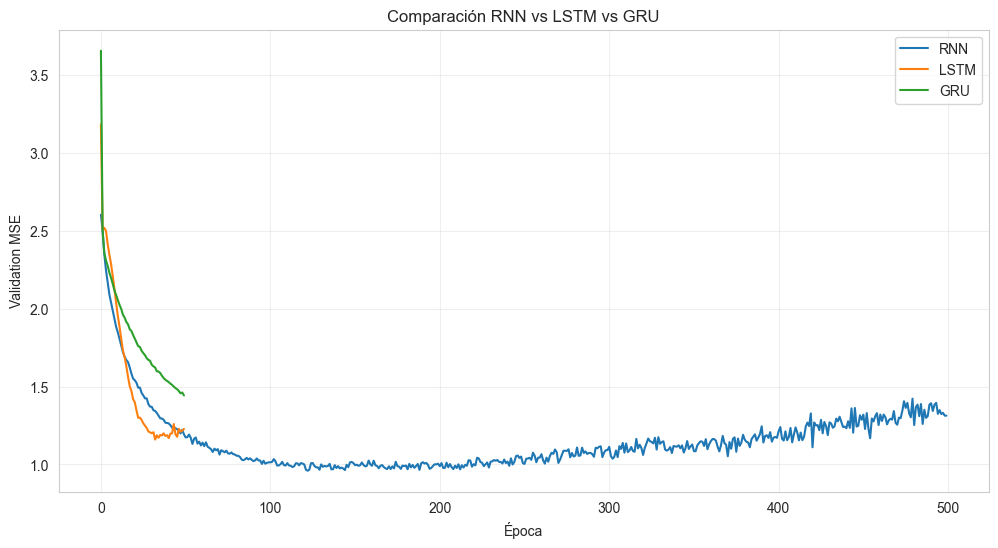

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    history["val_loss"],
    label="RNN"
)

plt.plot(
    history_lstm["val_loss"],
    label="LSTM"
)

plt.plot(
    history_gru["val_loss"],
    label="GRU"
)

plt.title("Comparación RNN vs LSTM vs GRU")
plt.xlabel("Época")
plt.ylabel("Validation MSE")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [76]:
def plot_prediction(
    model,
    dataset,
    idx,
    scaler_X,
    scaler_y,
    features,
    device
):

    model.eval()

    X_sample, y_sample = dataset[idx]

    # Agregar dimensión batch:
    # [30, 6] -> [1, 30, 6]
    X_input = (
        X_sample
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        y_pred = model(
            X_input
        )

    # ------------------------------------------
    # Valor real futuro
    # ------------------------------------------

    y_real = scaler_y.inverse_transform(
        y_sample
        .numpy()
        .reshape(-1, 1)
    )[0, 0]

    # ------------------------------------------
    # Predicción futura
    # ------------------------------------------

    y_pred_real = scaler_y.inverse_transform(
        y_pred
        .cpu()
        .numpy()
        .reshape(-1, 1)
    )[0, 0]

    # ------------------------------------------
    # Recuperar los precios Close de los
    # 30 días de entrada
    # ------------------------------------------

    X_np = X_sample.numpy()

    close_index = features.index(
        "close"
    )

    # Como scaler_X escala 6 columnas,
    # debemos desnormalizar todas
    X_original = scaler_X.inverse_transform(
        X_np
    )

    close_history = X_original[
        :,
        close_index
    ]

    # ------------------------------------------
    # Eje temporal
    # ------------------------------------------

    x_history = np.arange(
        len(close_history)
    )

    x_future = len(
        close_history
    )

    # ------------------------------------------
    # GRÁFICA
    # ------------------------------------------

    plt.figure(
        figsize=(14, 6)
    )

    # Historial
    plt.plot(
        x_history,
        close_history,
        marker="o",
        label="Close últimos 30 días"
    )

    # Real
    plt.scatter(
        x_future,
        y_real,
        s=120,
        label="Close real siguiente día"
    )

    # Predicción
    plt.scatter(
        x_future,
        y_pred_real,
        s=120,
        marker="X",
        label="Predicción RNN"
    )

    # Conectar último precio con real
    plt.plot(
        [
            x_history[-1],
            x_future
        ],
        [
            close_history[-1],
            y_real
        ],
        linestyle="--",
        alpha=0.5
    )

    # Conectar último precio con predicción
    plt.plot(
        [
            x_history[-1],
            x_future
        ],
        [
            close_history[-1],
            y_pred_real
        ],
        linestyle="--",
        alpha=0.5
    )

    plt.axvline(
        x=x_future - 0.5,
        linestyle="--",
        alpha=0.5
    )

    error = abs(
        y_real - y_pred_real
    )

    plt.title(
        f"Predicción muestra {idx}\n"
        f"Real={y_real:.4f} | "
        f"Predicho={y_pred_real:.4f} | "
        f"Error={error:.4f}"
    )

    plt.xlabel("Días")
    plt.ylabel("Close")

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [78]:
test_dataset_eval = TimeSeriesDataset(
    X_test,
    Y_test
)

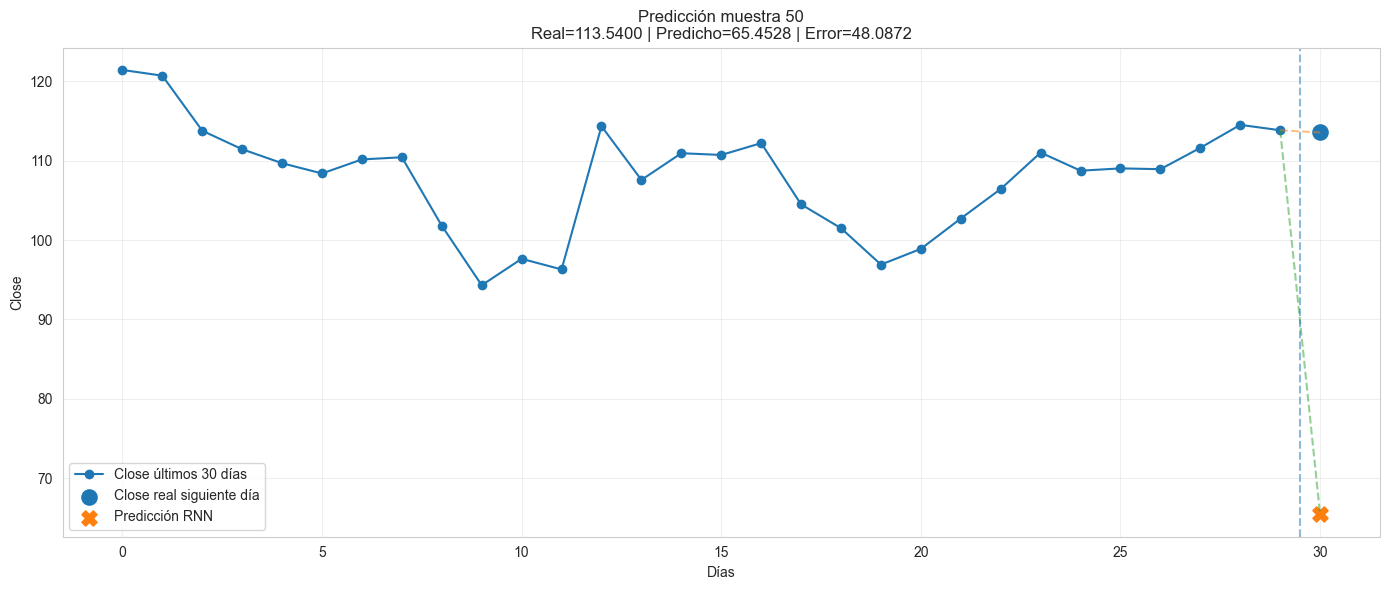

In [83]:
plot_prediction(
    lstm,
    test_dataset_eval,
    idx=50,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    features=features,
    device=device
)